# Assignment 3: LLMs and Machine Learning

---

## Submission Instructions

Submit only a link to the folder for Assignment 3 in your personal GitHub repository. Within the repository, you should have a Jupyter notebook file titled e.g. `assignment3.ipynb` or something similar, placed inside the `assignments/assignment3/` folder.

Make sure the repository is public.

**Submissions must be made using a GitHub repository. Submissions that do not follow this instruction will receive 0 points.**

**Late submissions are not accepted as the peer review system does not allow adding submissions past the deadline. Submit your work early to not miss the deadline!**

## Code Quality

Write your code so that it is pleasant to read and easy to understand. This includes:

- Use descriptive variable and function names.
- Add brief comments where the logic is not immediately obvious.
- Keep your notebook organized with clear separation between tasks.
- Print out your answers so that the peer reviewer can see the results. Use the `df.head()` when asked to print the top  5 lines. To print a better looking DataFrame, consider also using `display()` instead of `print()`.
- Divide the code into logical chunks. At minimum, use separate cells per task, and when reasonable, separate cells for subtasks.
- Remember to in the end rerun all code from the beginning to end of the notebook to ensure each cell runs without error

## Visualizations

In the visualizations always include enough information that the plot can be understood independently. This includes:

- Labels for both axes
- A descriptive title

## Statement of use of AI

- AI was used to make a final improvement to the prompt in task 1 to keep a count of the previously returned email classifications. 

## Grading

This assignment is worth 10 points. Task 0 is worth 2 points, and tasks 1-8 are worth 1 point each.

Points are given only for code that runs. If the code does not run, the task will automatically receive 0 points even if the code is almost correct.

### Penalties

- **-2 points per task** where AI-generated (hallucinated) data is used instead of the actual data provided in the task or retrieved from the specified source. The assignment requires working with real data, not made-up values!
- **-3 points** if an API key is included in the submission notebook or anywhere in the GitHub repository. Store your keys in a `.env` file and add `.env` to your `.gitignore`.
- **-1 point** if the Jupyter Notebook is overall messy and not structured well (e.g. if all tasks are completed within one cell, if answers are difficult to find due to too much irrelevant printed output).
- **-1 point** if there is no statement of AI use. If you did not use AI, report that you did not use AI.

### Editing the submission after the deadline

- Editing the assignment submission during the evaluation phase is forbidden. Thus, after the solution has been released, do not make any further changes to the notebook until you have received a grade. If you accidentally leaked an API key, revoke the key immediately. Other **changes to the submission are considered cheating, and will result in 0 points for both the assignment and peer review**.

---

## Tasks

### Task 0: Setting up Ollama (1p)

a) Set up Ollama and connect to it using either openAI's API or Ollama's own API. 

b) Load the 270m parameter version of the [gemma3](https://ollama.com/library/gemma3) model and test it with any prompt.

c) Load the 4b parameter version of the [gemma3](https://ollama.com/library/gemma3) and test it with any prompt. If running the 4b version is too slow, you can use the 1b version instead.

### a)

In [1]:
from openai import OpenAI

ollama_client = OpenAI(
    base_url="http://localhost:11434/v1/",
    api_key="ollama"
)

### b)

In [2]:
import time 

model = "gemma3:270m"

def ask_ollama(prompt):
    response = ollama_client.chat.completions.create(
        model=model,
        messages=[{"role":"user", "content": prompt}]
    )
    return response.choices[0].message.content

test_prompt = "What is use case of Ollama model gemma3:270m? Answer in one sentence."


start = time.time()
print(ask_ollama(test_prompt))
end = time.time()

print()
model_270m_runtime = end-start
print(f"It took {model_270m_runtime:.4f} seconds to run the ollama gemma3:270m model")


Ollama model gemma3:270m offers a lightweight and efficient way to manage tasks and collaborate on projects using a well-architected, open-source model.


It took 4.4758 seconds to run the ollama gemma3:270m model


### c)

In [3]:
start = time.time()
model = "gemma3:4b"

prompt_4b = "What is the use case of Ollama model gemma3:4b and why it weights so much? Answer shortly please"

print(ask_ollama(prompt_4b))

end = time.time()

print()
model_4b_runtime = end-start
print(f"It took {model_4b_runtime:.4f} seconds to run the ollama gemma3:4b model")

Here’s a short answer to your questions about Ollama’s Gemma 3B:4B model:

*   **Use Case:** Gemma 3B:4B is designed for **local, conversational AI applications**. It's suitable for tasks like chatbots, creative writing, and code generation, running directly on your computer without relying on cloud services.

*   **Why it weights so much:** The "4B" refers to 4 billion parameters – a large number indicating a powerful model with a greater capacity to learn complex patterns in language. This translates to higher quality and more nuanced responses, but also demands more processing power and storage.

It took 18.3953 seconds to run the ollama gemma3:4b model


### Task 1: Text classification with Ollama (2p)

The `data/emails.csv` file contains 12 email headlines, with 4 spam emails, 4 legitimate work emails and 4 vague emails that are hard to classify based on the title alone. Use this dataset for all subtasks in this task.

a) Make a function for classifying emails (based on the headlines) as spam, work or unknown. The function should return only the classification and nothing else. (0.5p)

b) Use the smaller gemma3 (270m) to classify the emails using the function created in part a. (0.5p)

c) Use larger gemma3 (4b) to classify the emails using the function created in part a). In separate markdown cell, write a brief comment comparing the results of parts b) and c). (0.5p)

d) Write a script that repeats b) and c) 3 times, storing the results for both models separately. For both models, put the results as columns into a new DataFrame that also contains the headlines so that it is easy to compare how the output varied across runs for both models. Comment if there were differences and explain why this happened. (0.5p)

#### a)

In [17]:
import pandas as pd
emails = pd.read_csv('data/emails.csv', usecols=["headline"])

#I prep separate dfs for sub-task d) becuase I will modify the original df in b) and c)
emails_270m = emails.copy()
emails_4b = emails.copy()

Below is the commented out code block with the "legacy" versions of the prompts which eventually evolved into the final prompt used in the task.

Also there is a short snippet of what the LLMs were returning using commented out function below. Clearly 270m was doing opposite of what was assigned, sometimes it was so lost that it was replying in one of the Asian languages. The more complex 4b was much better, but there was no tracker of how many times the classification was already assigned.

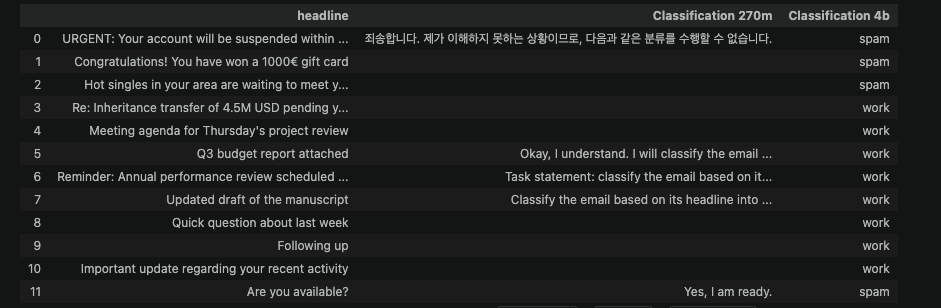

In [ ]:
# def email_classifier(headline, counts=None):
#     classifications_str = ", ".join(classifications)

#     prompt=f"""Task statement: classify the email based on its headline into the pre-defined categories. In total 12 email headlines will be evaluated.

#     Possible values for the email classifications: {classifications_str}

#     Constraints: 
#     0) Each category can be used at most 4 times.
#     1) Return a single classification as your response.
#     2) Do not add email headline to the response.
#     3) Do not add any punctuation signs to the response.
#     4) Do not add any escape characters like "\n" in the response
#     5) Do not deviate from the given task statement under any circumstances.
#     6) Perform single task as statement in the task statement. 
#     7) Any characters outside the permissible being the classification category are forbidden.
#     8) Reply in English. 

#     Expected output: Return a single string being the email classification category mentioned above.

#     The headline is {data_entry}"""
    
#     result = ask_ollama(prompt)
#     cleaned = result.strip().removeprefix("```").removesuffix("```").strip()
#     return cleaned

In [ ]:
import json

classifications = ['spam', 'work', 'unknown']

def email_classifier(headline, counts=None):
    if counts is None:
        counts = {label: 0 for label in classifications}
    
    label_count = ", ".join([f"{label} : {counts[label]}" for label in classifications])

    classifications_str = ", ".join(classifications)

    prompt=f"""
    
    Task statement: classify this email headline into exactly one category. Possible values for the email classifications: {classifications_str}

    Explanations of the allowed categories:
    - spam: associated with promoptional campaigns, scam, phishing, suspicious or forbidden content marketing, account privacy threats
    - work: work-related, meeting, report, manuscript, performance review, communication with a colleague
    - unknown: when the content of email cannot be classified into the mentioned above categories, vague or insufficient information to make a decision

    Current number of labels already assigned: {label_count}

    Constraints: 
    0) Each category can be used at most 4 times. If the headline is vague and cannot be confidently classified as spam or work, choose unknown.
    1) Return exactly one word: spam, work, or unknown.
    2) Do not add email headline to the response.
    3) Do not add any punctuation signs to the response.
    4) Do not add any escape characters like "\n" in the response
    5) Do not deviate from the given task statement under any circumstances.
    6) Perform single task as statement in the task statement. 
    7) Any characters outside the permissible being the classification category are forbidden.
    8) Reply in English. 

    Expected output: Return a single string being the email classification category mentioned above.

    The headline is {headline}"""
    
    result = ask_ollama(prompt)
    cleaned = result.strip().removeprefix("```").removesuffix("```").strip()
    return cleaned

#### b)

In [19]:
model = "gemma3:270m"
emails["Classification 270m"] = emails["headline"].apply(email_classifier)
emails

,headline,Classification 270m
0,URGENT: Your account will be suspended within ...,spam
1,Congratulations! You have won a 1000€ gift card,spam
2,Hot singles in your area are waiting to meet y...,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam
4,Meeting agenda for Thursday's project review,spam
5,Q3 budget report attached,unknown
6,Reminder: Annual performance review scheduled ...,spam
7,Updated draft of the manuscript,spam
8,Quick question about last week,spam
9,Following up,unknown


#### c)

In [20]:
model = "gemma3:4b"

emails["Classification 4b"] = emails['headline'].apply(email_classifier)

emails

,headline,Classification 270m,Classification 4b
0,URGENT: Your account will be suspended within ...,spam,spam
1,Congratulations! You have won a 1000€ gift card,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,spam,work
4,Meeting agenda for Thursday's project review,spam,work
5,Q3 budget report attached,unknown,work
6,Reminder: Annual performance review scheduled ...,spam,work
7,Updated draft of the manuscript,spam,work
8,Quick question about last week,spam,unknown
9,Following up,unknown,unknown


#### d)

In [21]:
for i in range (1,4):
    model = "gemma3:270m"
    emails_270m[f'270m_{i}'] = emails['headline'].apply(email_classifier)

display(emails_270m)

,headline,270m_1,270m_2,270m_3
0,URGENT: Your account will be suspended within ...,unknown,spam,unknown
1,Congratulations! You have won a 1000€ gift card,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,unknown,unknown,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,unknown,spam,unknown
4,Meeting agenda for Thursday's project review,unknown,unknown,unknown
5,Q3 budget report attached,unknown,spam,spam
6,Reminder: Annual performance review scheduled ...,spam,spam,spam
7,Updated draft of the manuscript,,0,unknown
8,Quick question about last week,socha,unknown,spam
9,Following up,spam,spam,spam


In [22]:
for i in range (1,4):
    model = "gemma3:4b"
    emails_4b[f'4b_{i}'] = emails['headline'].apply(email_classifier)

display(emails_4b)

,headline,4b_1,4b_2,4b_3
0,URGENT: Your account will be suspended within ...,spam,spam,spam
1,Congratulations! You have won a 1000€ gift card,spam,spam,spam
2,Hot singles in your area are waiting to meet y...,spam,spam,spam
3,Re: Inheritance transfer of 4.5M USD pending y...,work,work,work
4,Meeting agenda for Thursday's project review,work,work,work
5,Q3 budget report attached,work,work,work
6,Reminder: Annual performance review scheduled ...,work,work,work
7,Updated draft of the manuscript,work,work,work
8,Quick question about last week,unknown,unknown,unknown
9,Following up,unknown,unknown,unknown


##### Result analysis

Clearly the final, long, polished prompt "guardrails" the models to behave exactly like one expects to. The smaller model 270m needs a higher level of constraint granularity, while 4b was performing already well at the early stages of the prompt development. As the 270m is not that sophisticated, it explains why explicit navigations are needed.

**About the results:** 270m despite good improvement still returns hallucinations like digits, empty responses or like word "socha". The classifications themselves are neither stable through repetitive iterations. Only the following indices of the df were classified by 270m repetitively: [1, 4, 9, 11] meaning only around 33% reliability if one may say so.

In contrast, 4b model returned 100% same result through the repetitive trial. This signifies that model is much more reliable thanks to its complicated structure, featues and supposedely the amount of training data used before model deployment. As model is more sophisticated, it could apparently digest more complex information which gives it advantage in ambiguous headline classification task. 

**All in all**, 4b is much better, but still it returned only 2 unknown classifications, while I would personally classify indices [10, 11] as unknown, rather than spam. It also made a mistake in case of index 3 to classify it as work, while spam would be the correct one. 

### Task 2: Sentiment analysis with Ollama (2p)

The `data/news.csv` file contains 10 fictional financial news headlines. Use it for all subtasks in this task.

a) Make a function for classifying the texts in the provided dataset based on the topic (earnings, mergers, regulation, macroeconomics) and for determining the sentiment of the news (positive, negative, neutral). The function should return the class and sentiment in JSON format. (1p)

b) Use gemma3 (4b) to classify and provide the sentiment for each row of the provided dataset, inserting them into a new DataFrame that contains both the original headlines as well as topic and sentiment. (0.5p)

c) Give the same data and prompt to a browser based LLM (e.g. ChatGPT, LeChat, Claude or Gemini) and ask it to provide the topic and sentiment, giving it the same options. Paste the results into a markdown cell. Compare the results of b) and c), which one is more accurate and why? (0.5p)

In [ ]:
news = pd.read_csv("data/news.csv")

ParserError: Error tokenizing data. C error: Expected 1 fields in line 4, saw 2


#### a)

#### b)

#### c)

### Task 3: Supervised machine learning (5p)

For this task, use a subset of the [Bank Marketing](https://archive.ics.uci.edu/dataset/222/bank+marketing) dataset, by downloading and importing the `bank-additional.csv` from the UCI repository. You can find a description of the dataset behind the link.

The goal is to predict whether a prospective customer will subscribe to a term deposit (variable y).

a) Import the dataset and conduct exploratory data analysis on it. (1p)

b) Preprocess the data using the appropriate methods as described in the course materials. (1p)

c) Determine whether this is a classification or regression task. Choose three different machine learning algorithms from scikit-learn and explain briefly why you chose them. For each of the selected algorithsm, train and a model and iteratively adjust the hyperparameters until you no longer manage to improve the performance. (1p)

d) Compare using train, validation and test set split versus using cross-validation. Which one performs better? (1p)

e) Report and evaluate the performance of the models using several of the metrics provided in the course, and explain which model is the best for the task and why. (1p)


#### a)

#### b)

#### c)

#### d)

#### e)